In [60]:
import numpy as np

In [61]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
    def fit(self,X, y):
        # init parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias=0

        for i in range(self.n_iters):
            y_predicted = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted-y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            

    def predict(self,X):
        y_predicted = np.dot(X, self.weights) + self.bias
        return y_predicted

    def mse(self,y_true,y_predicted):
        
        return np.mean((y_true-y_predicted)**2)



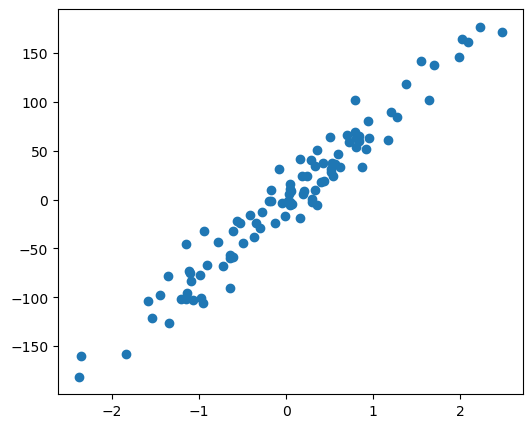

In [62]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
X, y = datasets.make_regression(n_samples=100, n_features =1, noise=20, random_state =4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
fig = plt.figure(figsize=(6,5))
plt.scatter(X[:, ], y)
plt.show()

In [63]:
import numpy as np
regressor = LinearRegression(lr=0.01) # for lr=0.001 mse is very high so use lr = 0.01
regressor.fit(X_train,y_train)
predicted = regressor.predict(X_test)
mse_value = regressor.mse(y_test, predicted)
print(mse_value)

298.0702596657663


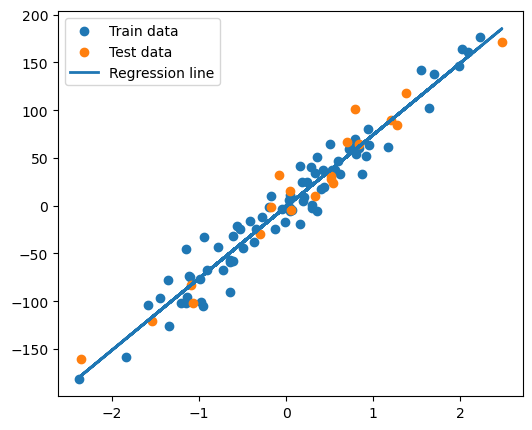

In [64]:
y_pred_line = regressor.predict(X)
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(X, y_pred_line, linewidth=2, label="Regression line")

plt.legend()
plt.show()